In [1]:
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from collections import Counter

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/cig_ps.zip"
EXTRACT_DIR = "/content/cig_ps"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

print("Dataset extracted!")

Dataset extracted!


In [9]:
!find /content/cig_ps -type d | head -20

/content/cig_ps
/content/cig_ps/cig_ps
/content/cig_ps/cig_ps/test_images
/content/cig_ps/cig_ps/train_images


In [10]:
BASE = "/content/cig_ps/cig_ps"

TRAIN_DIR = f"{BASE}/train_images"
TEST_DIR = f"{BASE}/test_images"
LABELS_CSV = f"{BASE}/train-labels.csv"

### Loading Dataset

In [11]:
train_files = sorted(os.listdir(TRAIN_DIR))
test_files  = sorted(os.listdir(TEST_DIR))

df = pd.read_csv(LABELS_CSV, index_col=0)

print(f"Train images: {len(train_files)}")
print(f"Test  images: {len(test_files)}")
print(f"Label rows in CSV: {len(df)}")
print()
print(df.head(5))
print()
print(df.dtypes)

Train images: 20000
Test  images: 5000
Label rows in CSV: 20000

         image    text
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR

image    object
text     object
dtype: object


### Checking for anomalous

In [12]:
bad_rows = []
for _, row in df.iterrows():
    label = str(row['text']).strip()
    if len(label) != 6 or not label.isalnum():
        bad_rows.append(row)

print(f"Anomalous rows found: {len(bad_rows)}")
for r in bad_rows:
    print(f"  idx={r.name}  image={r['image']}  label={repr(r['text'])}")

Anomalous rows found: 2
  idx=2184  image=train-2184.png  label='5.40E+12'
  idx=6819  image=train-6819.png  label='04-Mar-54'


In [14]:
# Cleaned dataframe
ANOMALOUS = {'train-2184.png', 'train-6819.png'}
df_clean = df[~df['image'].isin(ANOMALOUS)].copy()
df_clean['text'] = df_clean['text'].str.strip()
print(f"\nClean rows: {len(df_clean)}")


Clean rows: 19998


### Vocab verification

In [15]:
all_chars = sorted(set(''.join(df_clean['text'].tolist())))
print(f"Vocab size : {len(all_chars)}")
print(f"Characters : {all_chars}")

# Confirm absent chars
absent = set('01ILO')
present_absent = absent.intersection(set(all_chars))
print(f"\nExpected absent (0,1,I,L,O) actually present: {present_absent if present_absent else 'None — confirmed absent'}")

# All labels length 6?
lengths = df_clean['text'].str.len()
print(f"\nLabel length distribution:")
print(lengths.value_counts().sort_index())


Vocab size : 31
Characters : ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

Expected absent (0,1,I,L,O) actually present: None — confirmed absent

Label length distribution:
text
6    19998
Name: count, dtype: int64


### Labels frequency and positions of occurences

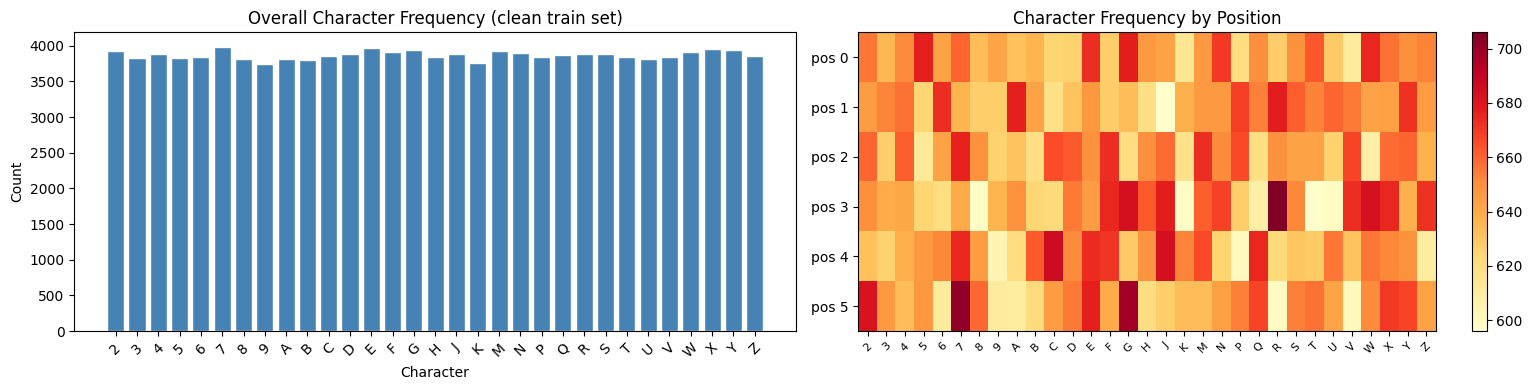

Saved label_statistics.png


In [16]:
labels = df_clean['text'].tolist()
all_text = ''.join(labels)

# Overall character frequency
char_freq = Counter(all_text)
chars_sorted = sorted(char_freq.keys())
freqs = [char_freq[c] for c in chars_sorted]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Overall frequency
axes[0].bar(chars_sorted, freqs, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Character Frequency (clean train set)')
axes[0].set_xlabel('Character')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Position-wise frequency heatmap
pos_freq = np.zeros((6, len(chars_sorted)), dtype=int)
for label in labels:
    for pos, ch in enumerate(label):
        if ch in chars_sorted:
            pos_freq[pos, chars_sorted.index(ch)] += 1

im = axes[1].imshow(pos_freq, aspect='auto', cmap='YlOrRd')
axes[1].set_yticks(range(6))
axes[1].set_yticklabels([f'pos {i}' for i in range(6)])
axes[1].set_xticks(range(len(chars_sorted)))
axes[1].set_xticklabels(chars_sorted, rotation=45, fontsize=8)
axes[1].set_title('Character Frequency by Position')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig('label_statistics.png', dpi=120)
plt.show()
print("Saved label_statistics.png")


### Sample images

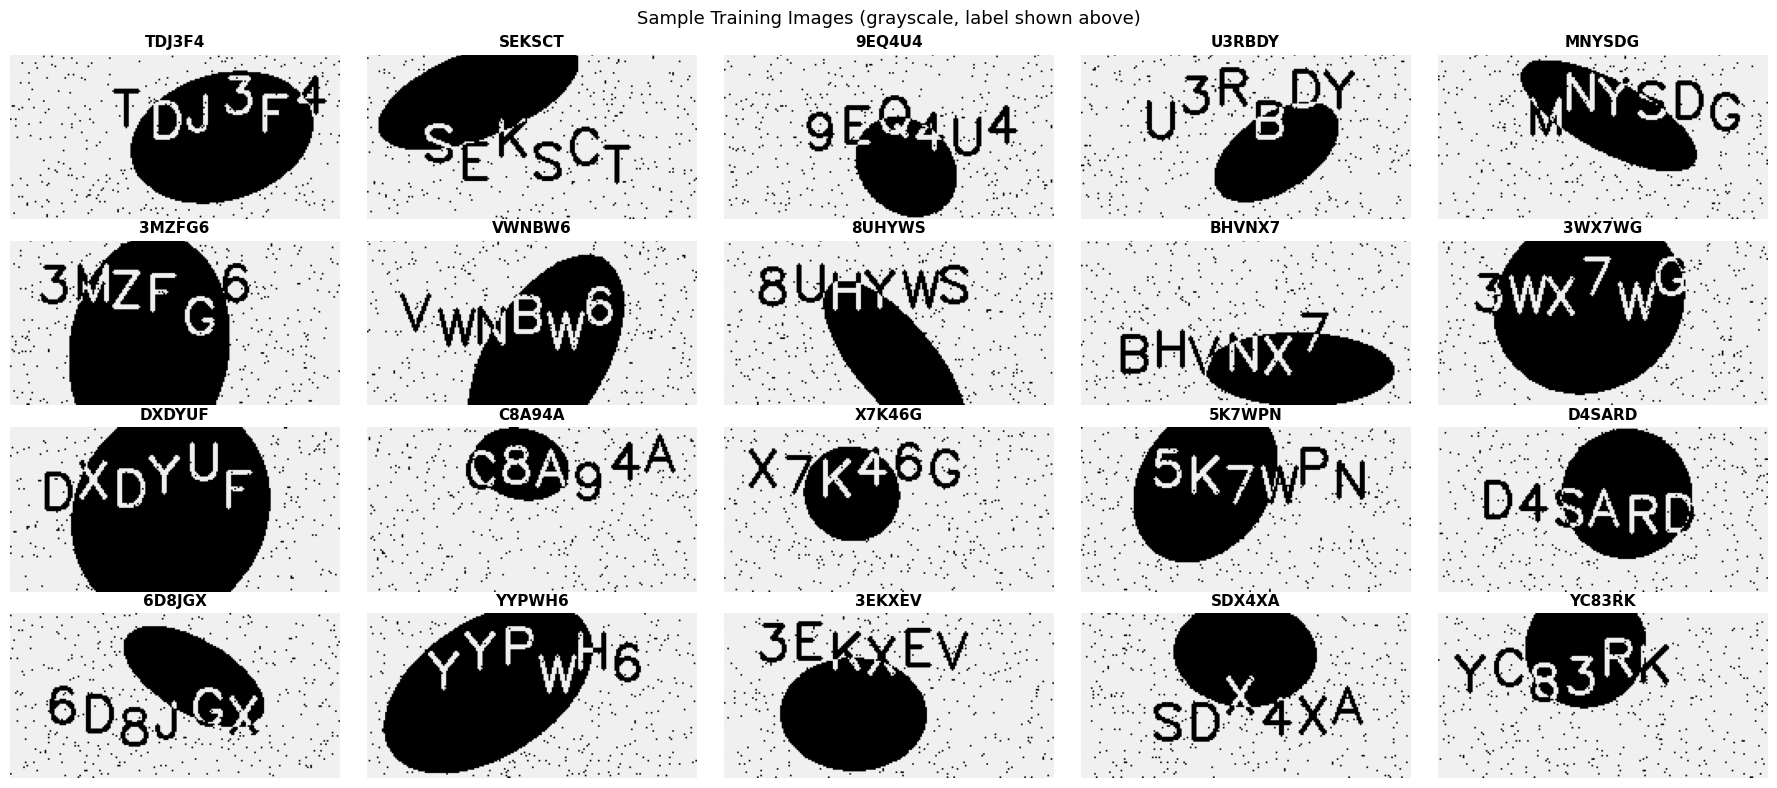

Saved sample_images.png


In [17]:
random.seed(42)
sample_rows = df_clean.sample(20, random_state=42)

fig, axes = plt.subplots(4, 5, figsize=(18, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = os.path.join(TRAIN_DIR, row['image'])
    img = Image.open(img_path).convert('L')
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(row['text'], fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Training Images (grayscale, label shown above)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120)
plt.show()
print("Saved sample_images.png")


### Image Dimensions & Pixel Statistics

In [18]:
# Check dimensions of first few images
shapes = set()
for fname in train_files[:100]:
    img = Image.open(os.path.join(TRAIN_DIR, fname))
    shapes.add(img.size)  # (W, H)
print("Unique (W, H) in first 100 train images:", shapes)

# Pixel statistics on a sample of 500 images
random.seed(0)
sample_files = random.sample(train_files, 500)

means, stds, mins_, maxs_ = [], [], [], []
for fname in sample_files:
    arr = np.array(Image.open(os.path.join(TRAIN_DIR, fname)).convert('L'), dtype=np.float32)
    means.append(arr.mean())
    stds.append(arr.std())
    mins_.append(arr.min())
    maxs_.append(arr.max())

print(f"\nPixel stats over 500-image sample:")
print(f"  Mean pixel value : {np.mean(means):.2f}  ± {np.std(means):.2f}")
print(f"  Std  pixel value : {np.mean(stds):.2f}  ± {np.std(stds):.2f}")
print(f"  Min  pixel value : {np.min(mins_):.1f}")
print(f"  Max  pixel value : {np.max(maxs_):.1f}")


Unique (W, H) in first 100 train images: {(200, 100)}

Pixel stats over 500-image sample:
  Mean pixel value : 173.00  ± 21.23
  Std  pixel value : 105.06  ± 10.08
  Min  pixel value : 0.0
  Max  pixel value : 240.0


### Mean image (average appearance)

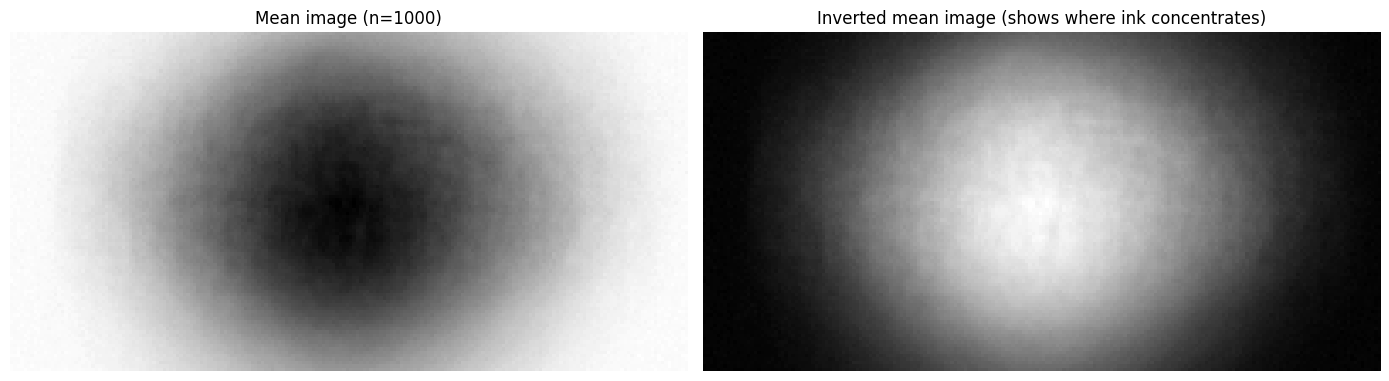

In [19]:
# Compute mean image over 1000 random training images
accum = np.zeros((100, 200), dtype=np.float64)
n = 1000
sample_k = random.sample(train_files, n)
for fname in sample_k:
    arr = np.array(Image.open(os.path.join(TRAIN_DIR, fname)).convert('L'), dtype=np.float64)
    accum += arr
mean_img = (accum / n).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(mean_img, cmap='gray')
axes[0].set_title(f'Mean image (n={n})')
axes[0].axis('off')

axes[1].imshow(255 - mean_img, cmap='gray')
axes[1].set_title('Inverted mean image (shows where ink concentrates)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('mean_image.png', dpi=120)
plt.show()
